## 1. Setup

In [1]:
import os
import time
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binomtest

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import keras

SEED = 316
keras.utils.set_random_seed(SEED)


class UpperQuantileClipper(BaseEstimator, TransformerMixin):
    """Clip each input column at a quantile learned from the training data only."""

    def __init__(self, quantile=0.99):
        self.quantile = quantile

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.upper_bounds_ = np.nanquantile(X, self.quantile, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.minimum(X, self.upper_bounds_)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.asarray([f"x{i}" for i in range(len(self.upper_bounds_))], dtype=object)
        return np.asarray(input_features, dtype=object)

## 2. Load the data

`load_census()` prefers a local `data/censusData.csv` (the course file, gitignored) and
otherwise downloads the public UCI Adult data and renames it into the same schema:
`sex` → `sex_selfID` with `Male` → `Non-Female`, `income` → `income_binary`,
`Amer-Indian-Eskimo` → `Amer-Indian-Inuit`, and `?` → `NaN`.

The committed outputs are from the public path.

In [2]:
COURSE_CSV = Path("data/censusData.csv")   # not redistributed; see note above
UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
UCI_CACHE = Path("data/adult.data")

UCI_COLUMNS = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income",
]


def load_census():
    if COURSE_CSV.exists():
        return pd.read_csv(COURSE_CSV)

    UCI_CACHE.parent.mkdir(parents=True, exist_ok=True)
    if not UCI_CACHE.exists():
        urllib.request.urlretrieve(UCI_URL, UCI_CACHE)

    df = pd.read_csv(
        UCI_CACHE, header=None, names=UCI_COLUMNS,
        skipinitialspace=True, na_values=["?"],
    )
    # match the schema the notebook was written against
    df = df.rename(columns={"sex": "sex_selfID", "income": "income_binary"})
    df["sex_selfID"] = df["sex_selfID"].replace({"Male": "Non-Female"})
    df["race"] = df["race"].replace({"Amer-Indian-Eskimo": "Amer-Indian-Inuit"})
    df["age"] = df["age"].astype(float)
    df["hours-per-week"] = df["hours-per-week"].astype(float)
    return df


df = load_census()
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## 3. Exploratory analysis

### 3.1 Class balance

Roughly 76/24. Moderate imbalance — not severe, but enough that accuracy is misleading,
since predicting "under 50K" for everyone already scores ~76%. Everything below leans on
F1 and on subgroup recall rather than accuracy.

In [3]:
pcts = df['income_binary'].value_counts(normalize=True) * 100
pcts

income_binary
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64

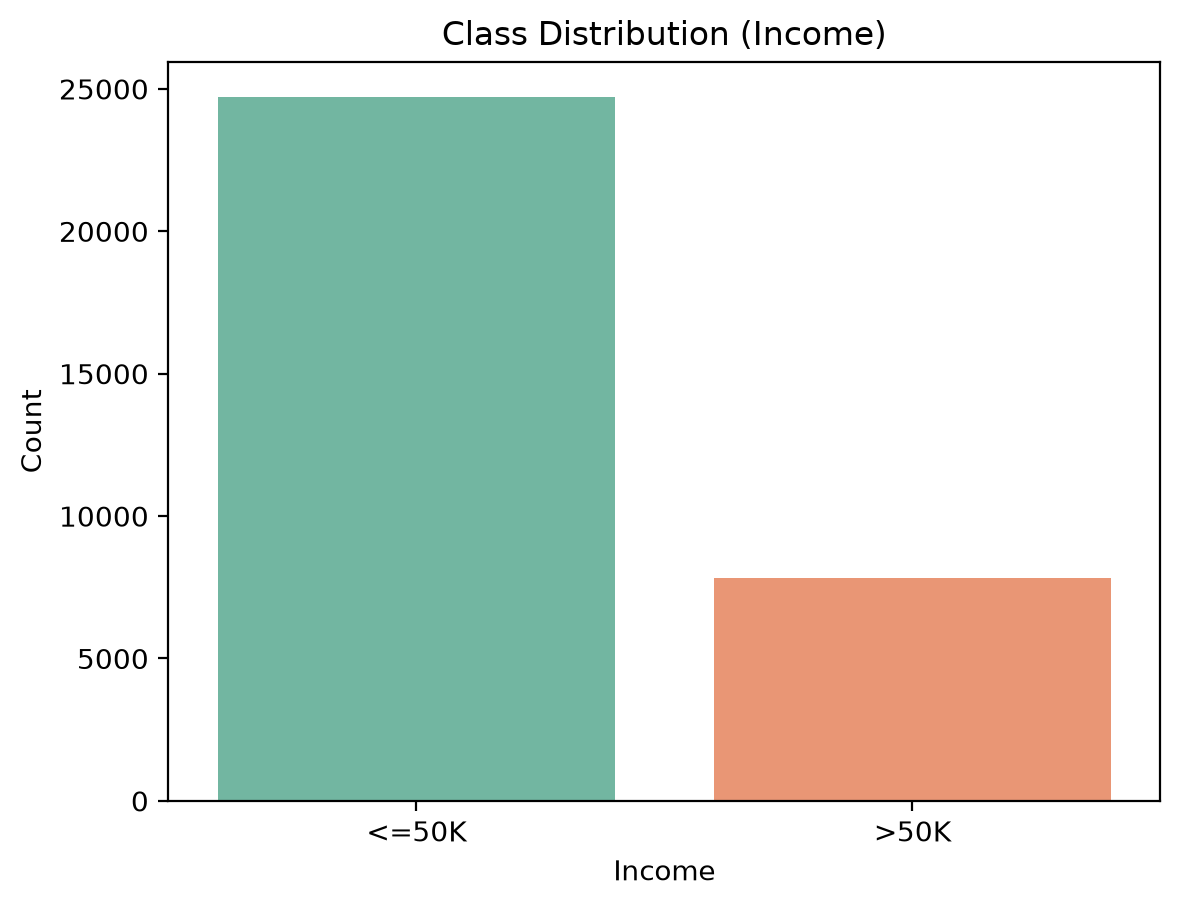

In [4]:
sns.countplot(data=df, x="income_binary", hue="income_binary", palette="Set2", legend=False)
plt.title("Class Distribution (Income)")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

### 3.2 Numeric features

`capital-gain` and `capital-loss` are zero for most rows with long right tails;
`hours-per-week` spikes hard at 40 with tails both directions; `age` is mildly right-skewed.
That argues for median imputation where needed and scaling before gradient-based models.

`capital-gain` also has a mass at 99,999 at the extreme upper end. Rather than letting those
rows dominate a standardized linear feature, section 4 now treats the amount as a
zero-inflated, heavy-tailed variable: it adds a separate `has_capital_gain` indicator,
clips `capital-gain` at a **99th-percentile cap learned on the training set only**, then
applies `log1p` before standardization. `capital-loss` gets the same zero/nonzero indicator
and `log1p`, but is not clipped because it does not have the same 99,999 spike.


In [5]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


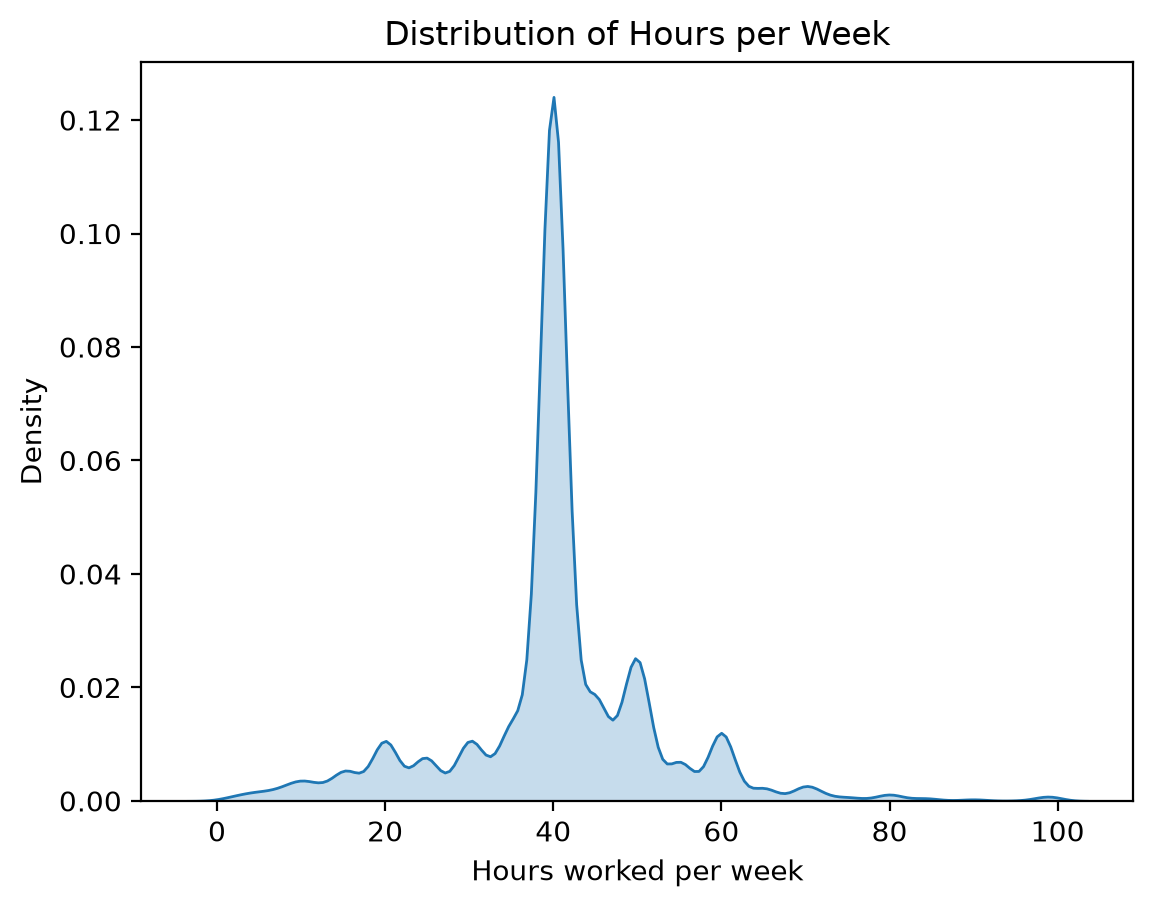

In [6]:
sns.kdeplot(data=df, x="hours-per-week", fill=True)
plt.title("Distribution of Hours per Week")
plt.xlabel("Hours worked per week")
plt.show()

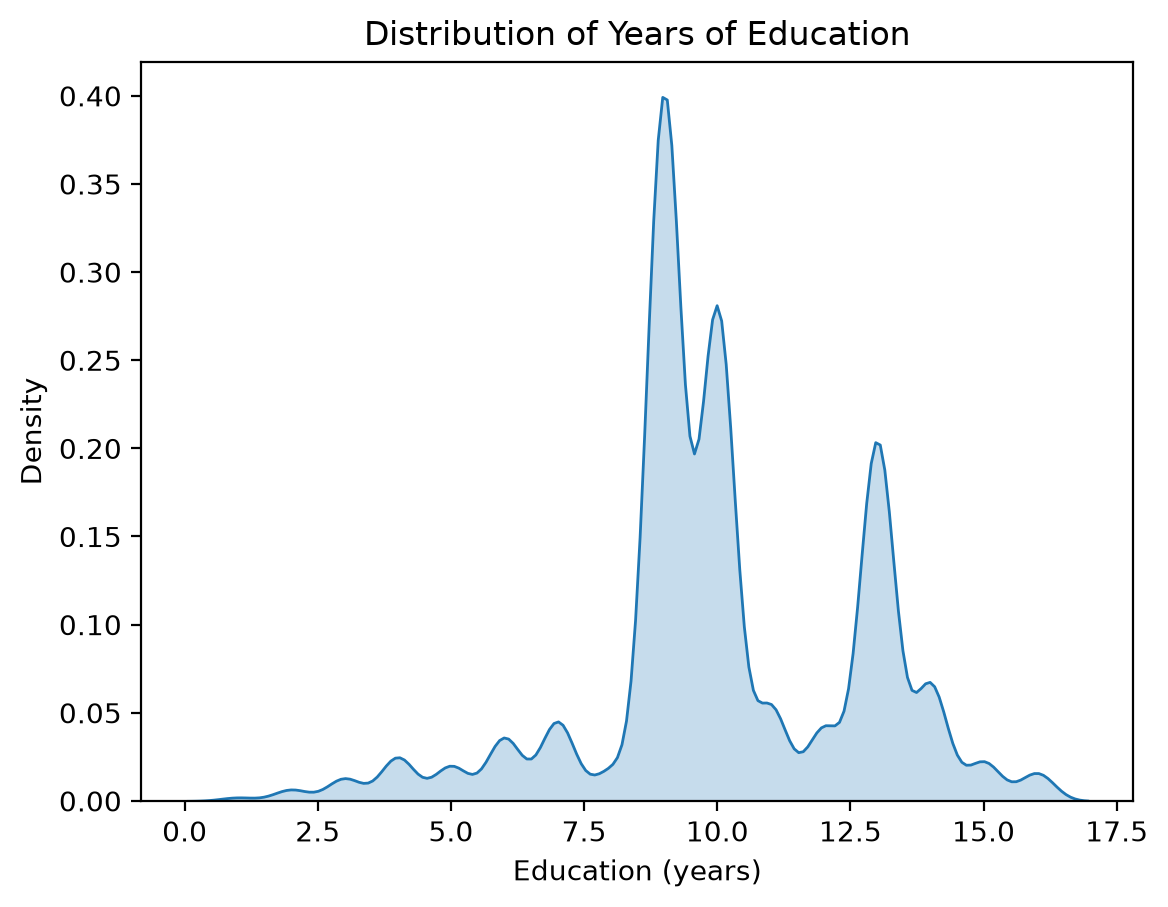

In [7]:
sns.kdeplot(data=df, x="education-num", fill=True)
plt.title("Distribution of Years of Education")
plt.xlabel("Education (years)")
plt.show()

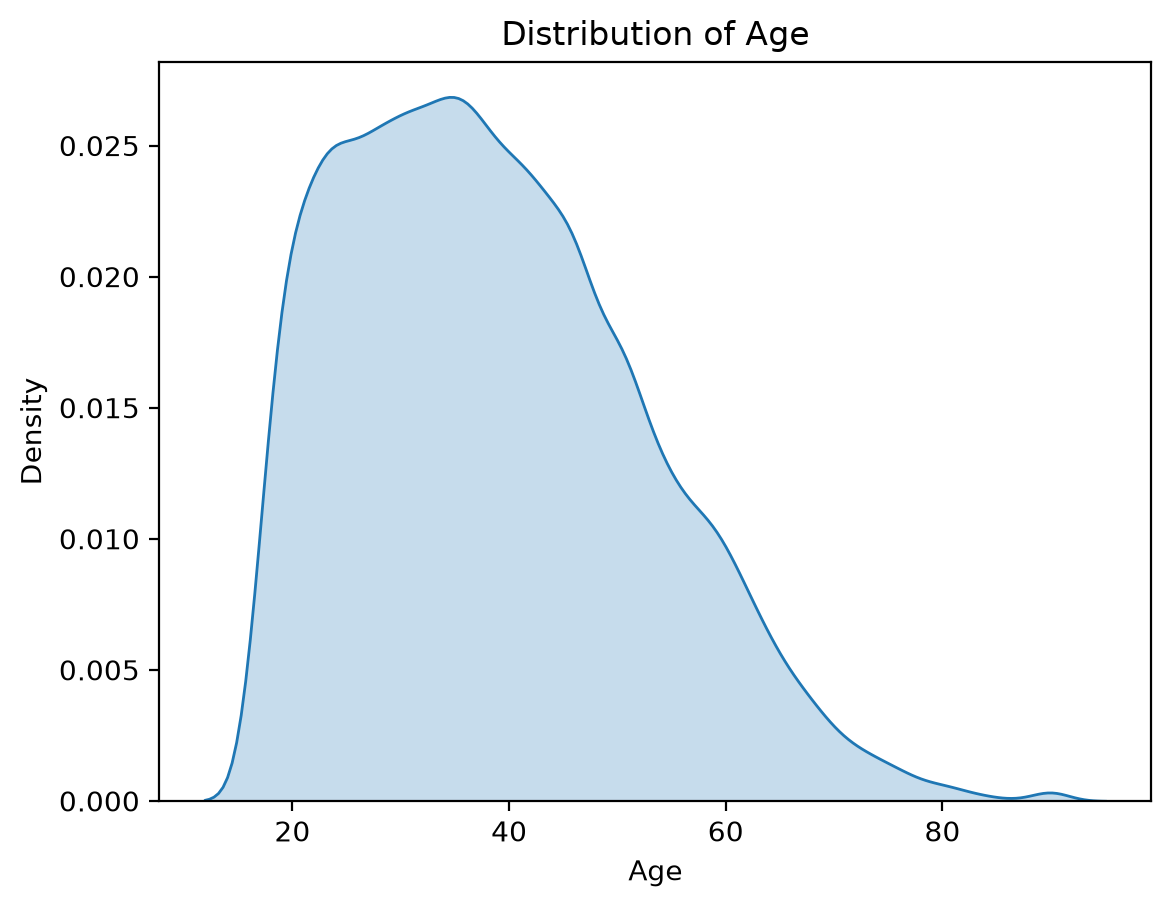

In [8]:
sns.kdeplot(data=df, x="age", fill=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.show()

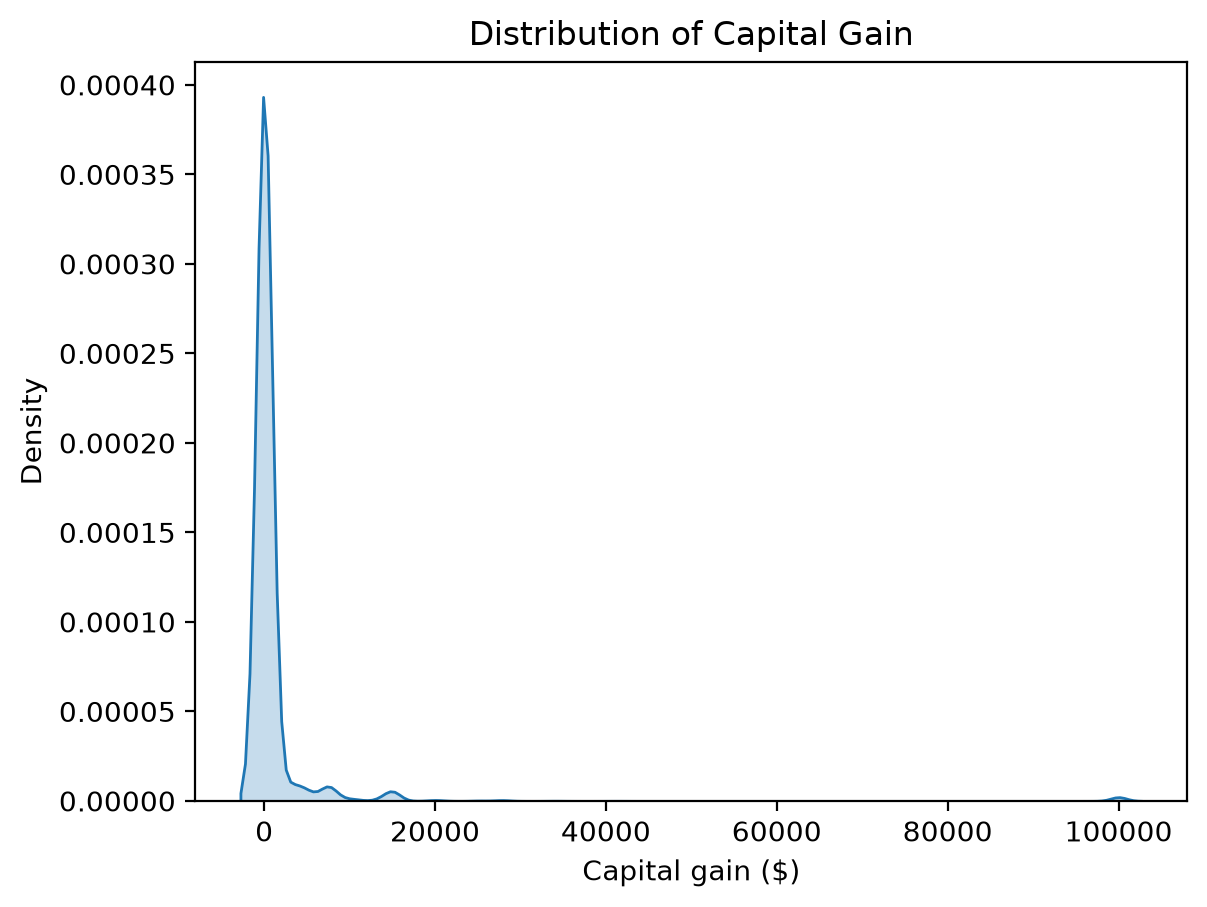

In [9]:
sns.kdeplot(data=df, x="capital-gain", fill=True)
plt.title("Distribution of Capital Gain")
plt.xlabel("Capital gain ($)")
plt.show()

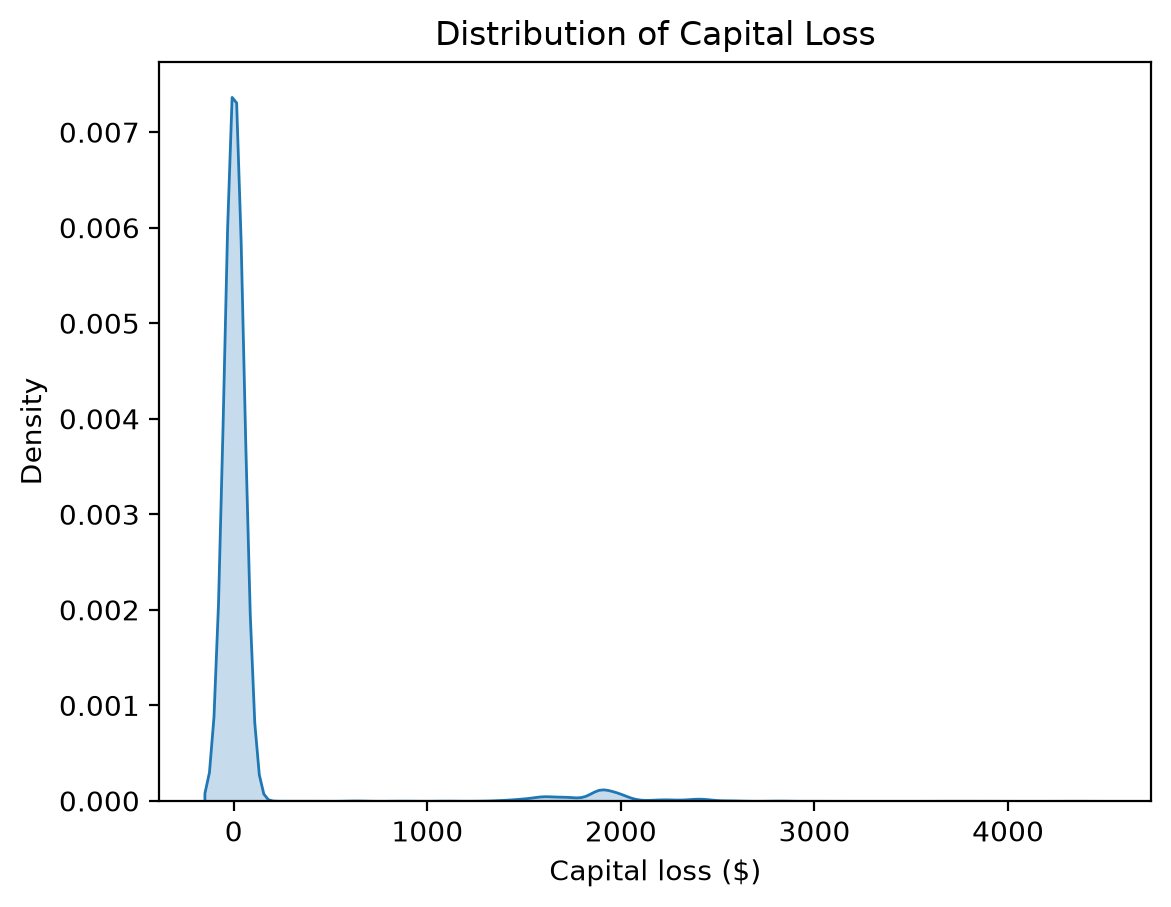

In [10]:
sns.kdeplot(data=df, x="capital-loss", fill=True)
plt.title("Distribution of Capital Loss")
plt.xlabel("Capital loss ($)")
plt.show()

### 3.3 Categorical features

In [11]:
print(df['income_binary'].unique().tolist())
print(df['sex_selfID'].unique().tolist())
print(df['race'].unique().tolist())
print(df['native-country'].unique().tolist())

['<=50K', '>50K']
['Non-Female', 'Female']
['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Inuit', 'Other']
['United-States', 'Cuba', 'Jamaica', 'India', nan, 'Mexico', 'South', 'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany', 'Iran', 'Philippines', 'Italy', 'Poland', 'Columbia', 'Cambodia', 'Thailand', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal', 'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala', 'China', 'Japan', 'Yugoslavia', 'Peru', 'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago', 'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary', 'Holand-Netherlands']


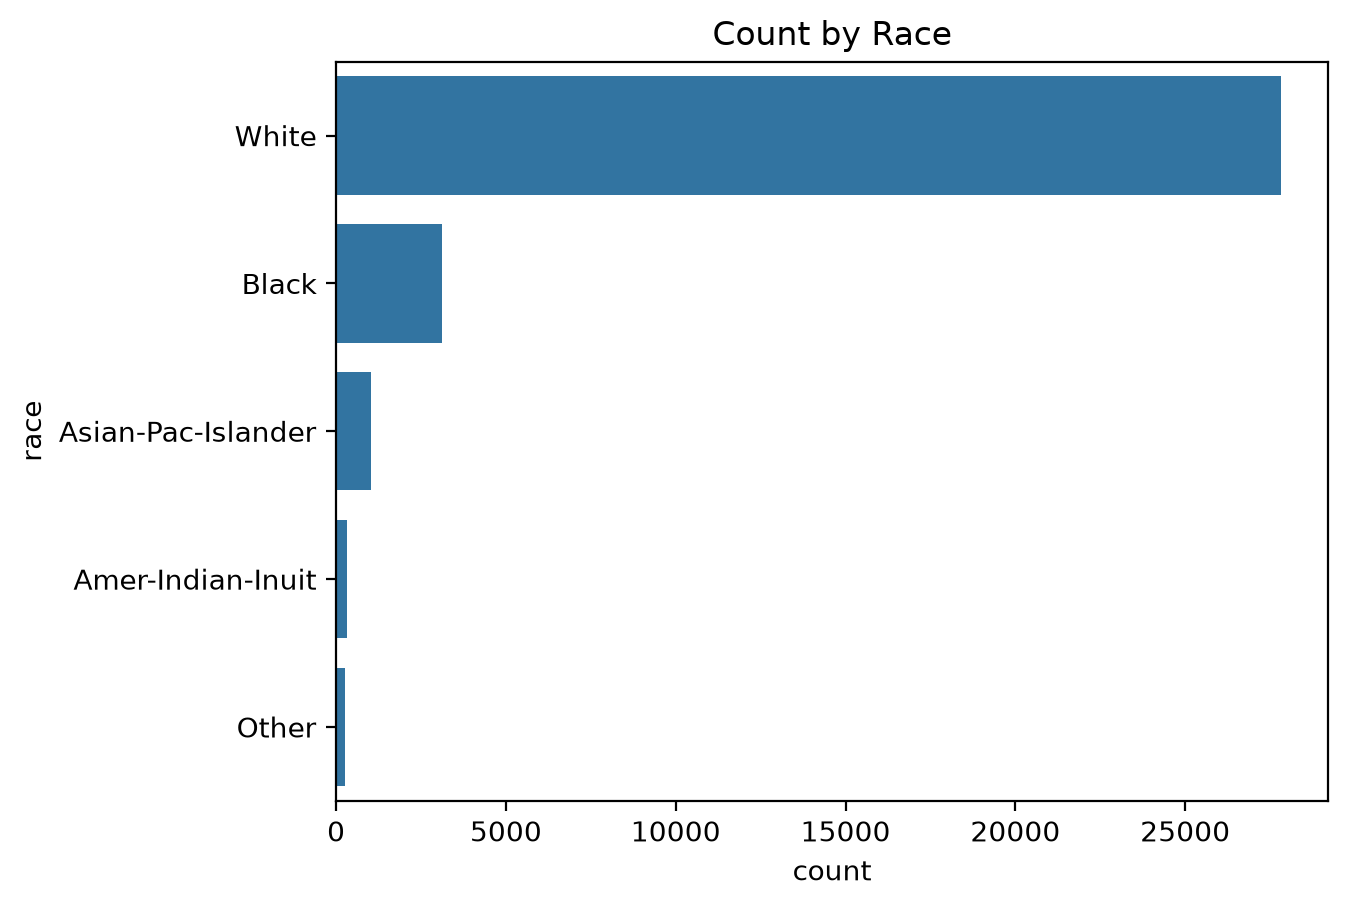

In [12]:
sns.countplot(y='race', data=df)
plt.title("Count by Race")
plt.show()

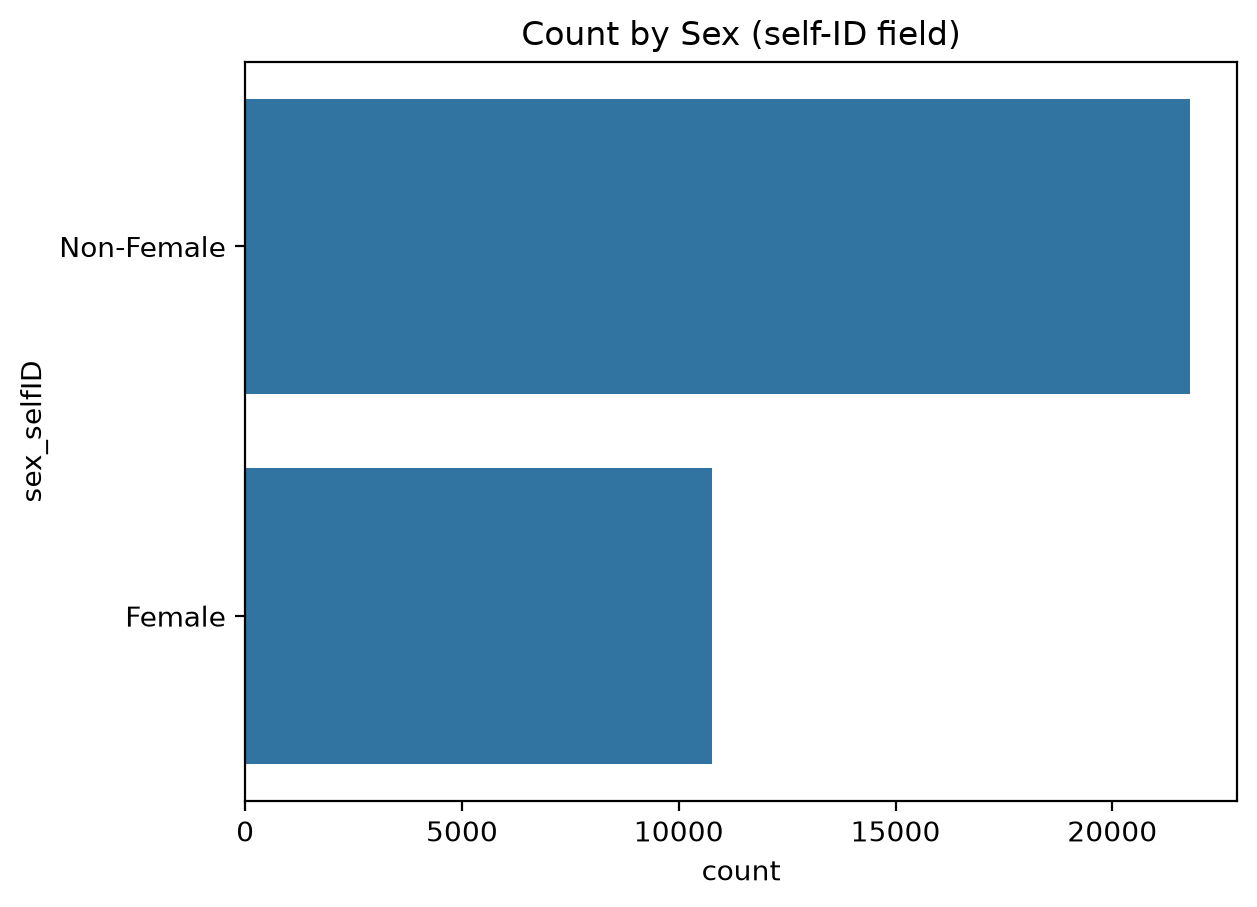

In [13]:
sns.countplot(y='sex_selfID', data=df)
plt.title("Count by Sex (self-ID field)")
plt.show()

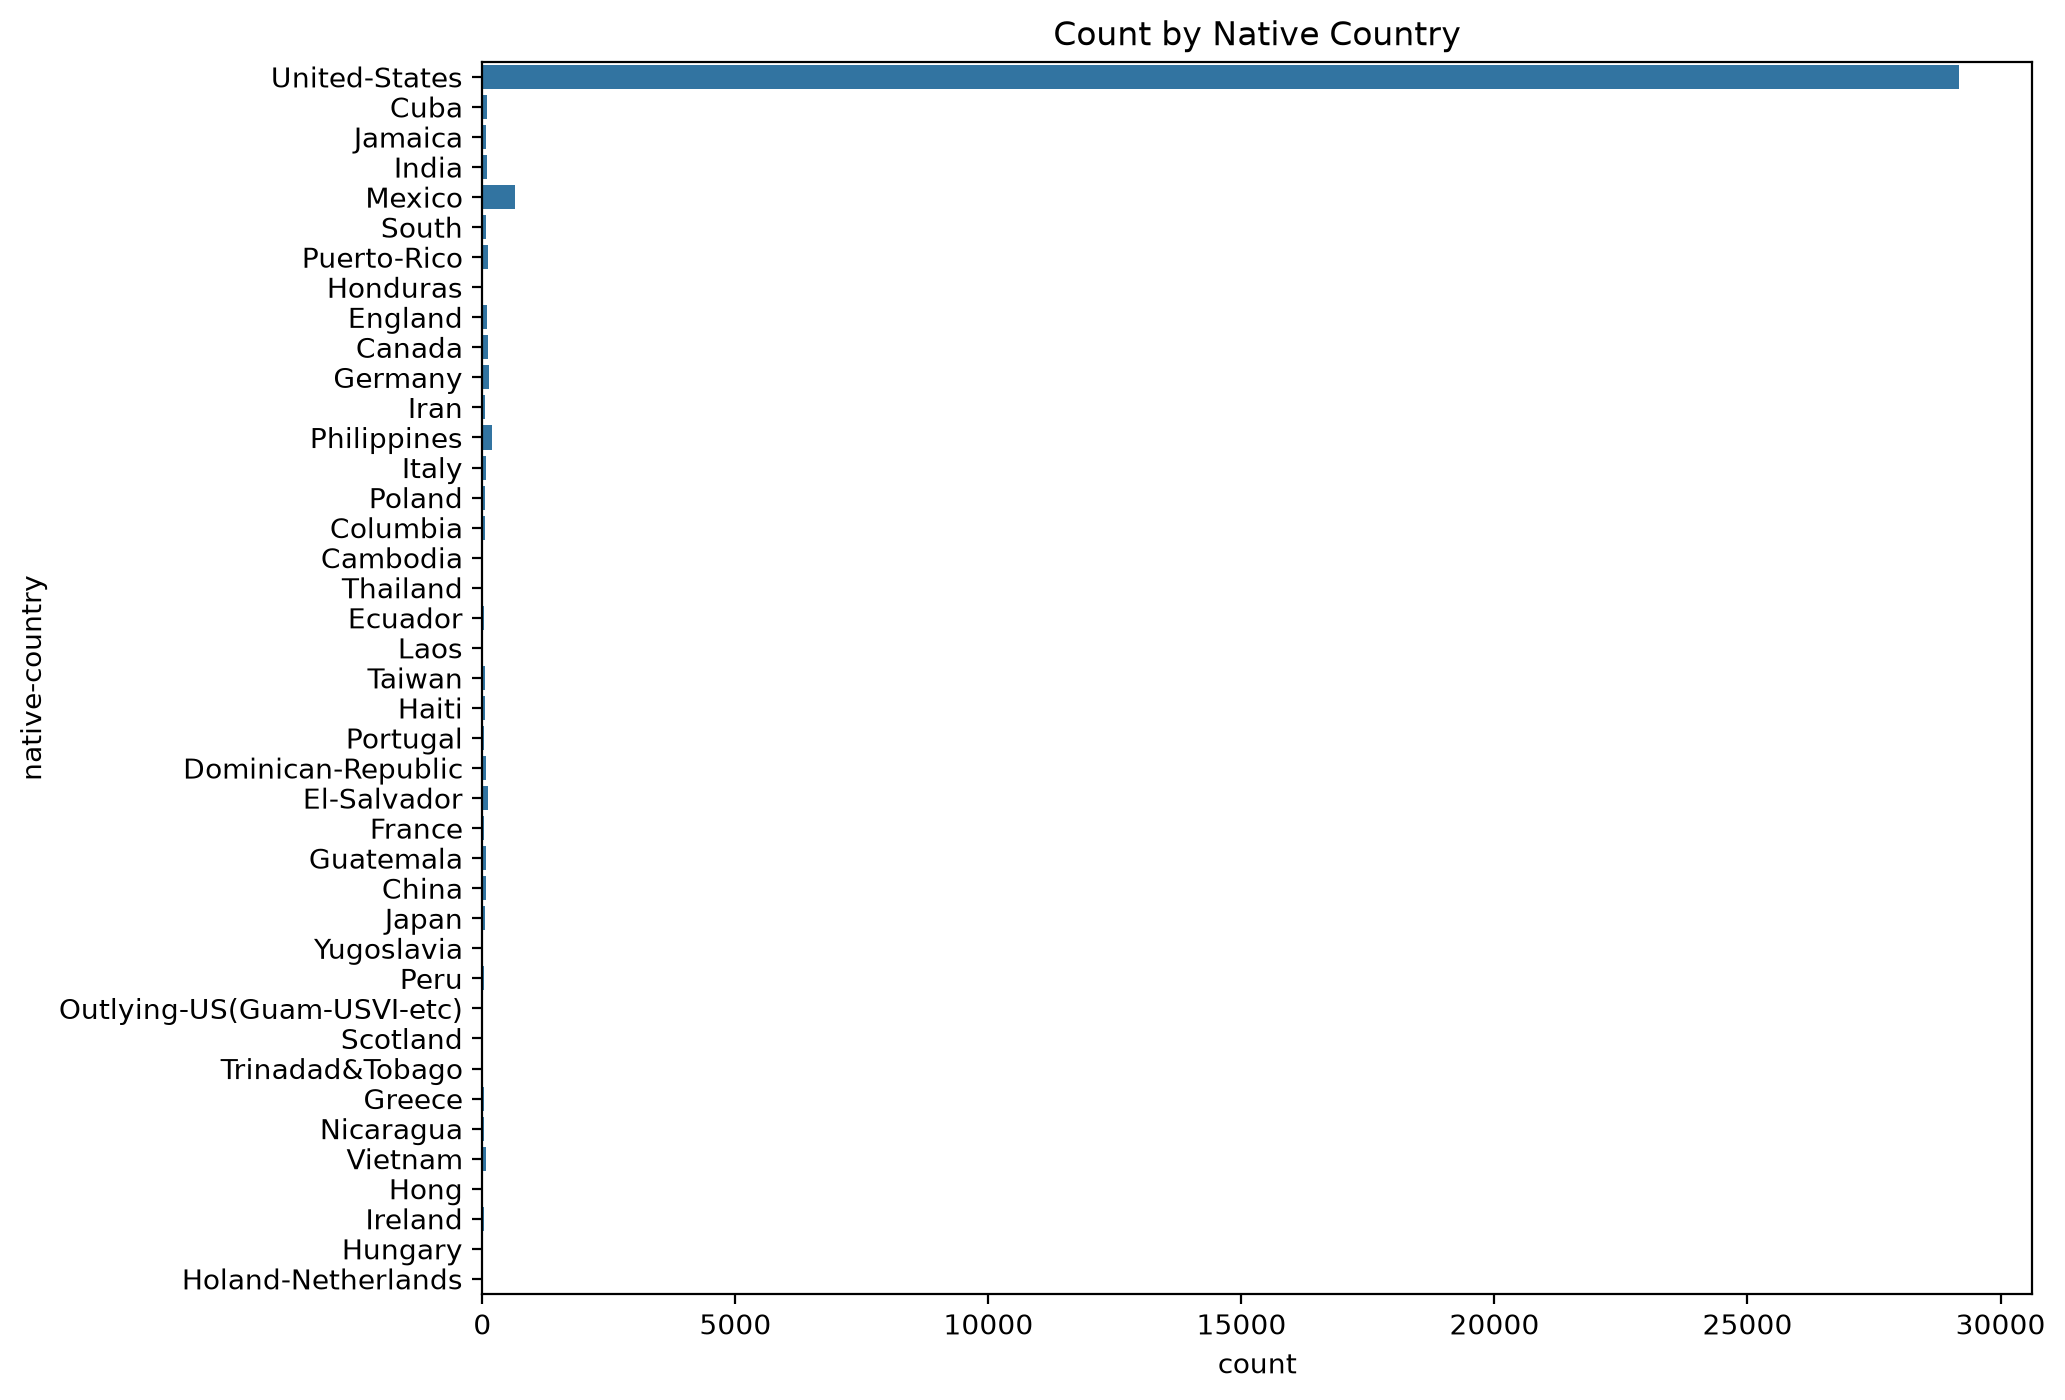

In [14]:
plt.figure(figsize=(10, 8))
sns.countplot(y='native-country', data=df)
plt.title("Count by Native Country")
plt.show()

In [15]:
print(df['native-country'].value_counts(normalize=True) * 100)

native-country
United-States                 91.218963
Mexico                         2.010757
Philippines                    0.619176
Germany                        0.428420
Canada                         0.378385
Puerto-Rico                    0.356495
El-Salvador                    0.331478
India                          0.312715
Cuba                           0.297079
England                        0.281443
Jamaica                        0.253299
South                          0.250172
China                          0.234536
Italy                          0.228282
Dominican-Republic             0.218900
Vietnam                        0.209519
Guatemala                      0.200138
Japan                          0.193883
Poland                         0.187629
Columbia                       0.184502
Taiwan                         0.159485
Haiti                          0.137595
Iran                           0.134467
Portugal                       0.115705
Nicaragua                

### 3.4 Sex and the label

This is the check that drives the rest of the notebook. The sample itself is about 67/33
non-female/female, so subgroup sizes are unequal before modeling begins. The more important
question for this analysis is whether the observed label rate differs by sex, and by how much.


In [16]:
df['is_female'] = df['sex_selfID'].map({'Female': 1, 'Non-Female': 0})
df['makes_over_50k'] = df['income_binary'].map({'>50K': 1, '<=50K': 0})

# Keep unknown native-country values unknown for EDA rather than silently calling them US-native.
df['is_US_native'] = np.where(
    df['native-country'].isna(),
    np.nan,
    (df['native-country'] == 'United-States').astype(float)
)
df['native_group'] = np.select(
    [df['native-country'].isna(), df['native-country'].eq('United-States')],
    ['Missing', 'US'],
    default='Non-US'
)

print("CORRELATIONS", end="\n\n")
female_corr = df['is_female'].corr(df['makes_over_50k'])
us_corr = df['is_US_native'].corr(df['makes_over_50k'])

print(f"Is female / makes over 50K: {female_corr}")
print(f"Is non-female / makes over 50K: {-female_corr}")
print("\n")
print(f"Is US-native / makes over 50K: {us_corr}")
print(f"Is non-US-native / makes over 50K: {-us_corr}")

CORRELATIONS

Is female / makes over 50K: -0.21598015058403677
Is non-female / makes over 50K: 0.21598015058403677


Is US-native / makes over 50K: 0.03921181135474828
Is non-US-native / makes over 50K: -0.03921181135474828


In [17]:
# positive rate within each sex
(pd.crosstab(df['is_female'], df['makes_over_50k'], normalize='index') * 100).round(2)

makes_over_50k,0,1
is_female,,
0,69.43,30.57
1,89.05,10.95


In [18]:
(pd.crosstab(df['is_female'], df['native_group'], normalize='index') * 100).round(2)

native_group,Missing,Non-US,US
is_female,,,
0,1.93,8.64,89.44
1,1.51,8.60,89.89


The sex gap in the label is large, so the rest of the notebook reports subgroup performance
directly rather than relying on aggregate accuracy. The native-country crosstab is now
three-way (`US`, `Non-US`, `Missing`) so missing values are not silently treated as
US-native.

`class_weight='balanced'` reweights the **label marginal**; it does not guarantee equal
performance inside the female and non-female subgroups. That conditional gap therefore has
to be measured explicitly in sections 5.2, 6.3, and 6.4.

### 3.5 Missingness

In [19]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income_binary        0
is_female            0
makes_over_50k       0
is_US_native       583
native_group         0
dtype: int64

In [20]:
df['occupation'].unique()

<StringArray>
[     'Adm-clerical',   'Exec-managerial', 'Handlers-cleaners',
    'Prof-specialty',     'Other-service',             'Sales',
      'Craft-repair',  'Transport-moving',   'Farming-fishing',
 'Machine-op-inspct',      'Tech-support',                 nan,
   'Protective-serv',      'Armed-Forces',   'Priv-house-serv']
Length: 15, dtype: str

### 3.6 EDA summary

- **Label:** ~76/24 imbalance. Use F1 and subgroup metrics, not accuracy alone.
- **Sex:** the positive rate differs sharply by sex, so aggregate performance can hide a
  materially different false-negative rate.
- **Missingness:** on the public file, `workclass`, `occupation`, and `native-country` contain
  the original `?` codes. `workclass` and `occupation` keep an explicit `"Missing"` category.
  `native-country` is represented with two model indicators: `is_US_native` and
  `native_country_missing`, leaving known non-US rows as the reference state.
- **Capital variables:** both are zero-inflated and strongly right-skewed. The modeling
  pipeline therefore separates zero/nonzero status from amount and transforms the amount
  rather than standardizing the raw scale.
- Median imputation for `age` and `hours-per-week` remains in the pipeline so the notebook
  works against either the public file or the course copy.

## 4. Data preparation

**Split first.** The notebook now uses a stratified **70/15/15 train/validation/test split**.
Anything that learns from the data — imputers, one-hot vocabularies, scaling parameters,
the `capital-gain` clipping threshold, model hyperparameters, early stopping, and prediction
thresholds — is fit or selected without looking at the final test set.

**Dropped columns.** `fnlwgt` is kept out of the feature matrix because it is a sampling
weight rather than a predictor. It is retained in the original frame for a weighted
sensitivity check later. `education` is redundant with `education-num`.

**Row-wise transforms.** `income_binary` becomes `makes_over_50k`; `sex_selfID` becomes
`is_female`. Missing native country is no longer filled as United States. Instead,
`is_US_native` and `native_country_missing` encode three states with known non-US as the
reference. `has_capital_gain` and `has_capital_loss` preserve whether either amount is zero.

**Fitted transforms.** Age, education number, and weekly hours are median-imputed and
standardized. `capital-gain` is median-imputed, clipped at the training-set 99th percentile,
`log1p` transformed, and standardized. `capital-loss` is median-imputed, `log1p` transformed,
and standardized. Categorical columns use a `"Missing"` category and one-hot encoding with
`drop='first'`.

In [21]:
df_lg = df.drop(columns=["fnlwgt", "education"]).copy()

df_lg['makes_over_50k'] = df_lg['income_binary'].map({'>50K': 1, '<=50K': 0})
df_lg['is_female'] = df_lg['sex_selfID'].map({'Female': 1, 'Non-Female': 0})

# Three-state native-country encoding:
# known non-US = (0, 0), US = (1, 0), missing = (0, 1)
df_lg['is_US_native'] = (df_lg['native-country'] == 'United-States').astype(int)
df_lg['native_country_missing'] = df_lg['native-country'].isna().astype(int)

# Preserve the important zero-vs-positive distinction before transforming the amounts.
df_lg['has_capital_gain'] = (df_lg['capital-gain'].fillna(0) > 0).astype(int)
df_lg['has_capital_loss'] = (df_lg['capital-loss'].fillna(0) > 0).astype(int)

df_lg = df_lg.drop(columns=["sex_selfID", "income_binary", "native-country"])

In [22]:
df_lg.isnull().sum()

age                          0
workclass                 1836
education-num                0
marital-status               0
occupation                1843
relationship                 0
race                         0
capital-gain                 0
capital-loss                 0
hours-per-week               0
is_female                    0
makes_over_50k               0
is_US_native                 0
native_group                 0
native_country_missing       0
has_capital_gain             0
has_capital_loss             0
dtype: int64

## 5. Logistic regression

The same 70/15/15 split is used for both model families. Logistic-regression hyperparameters
are selected by 5-fold cross-validation **inside the training set**. Its probability
threshold is then selected on the validation set for F1, and the final test set is evaluated
once at that frozen threshold.

In [23]:
label = 'makes_over_50k'

X = df_lg.drop(columns=label)
y = df_lg[label]

# 70% train, 30% holdout; then split the holdout evenly into validation and test.
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_holdout, y_holdout,
    test_size=0.50,
    stratify=y_holdout,
    random_state=SEED
)

print("train:", X_train.shape, "validation:", X_val.shape, "test:", X_test.shape)

train: (22792, 16) validation: (4884, 16) test: (4885, 16)


In [24]:
y_train.describe()

count    22792.000000
mean         0.240830
std          0.427597
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: makes_over_50k, dtype: float64

In [25]:
y_test.describe()

count    4885.000000
mean        0.240737
std         0.427575
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: makes_over_50k, dtype: float64

In [26]:
numeric_cols = ['age', 'education-num', 'hours-per-week']
capital_gain_cols = ['capital-gain']
capital_loss_cols = ['capital-loss']

categorical_cols = ['workclass', 'occupation', 'marital-status', 'relationship', 'race']
passthrough_cols = [
    'is_female',
    'is_US_native',
    'native_country_missing',
    'has_capital_gain',
    'has_capital_loss',
]

In [28]:
numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

capital_gain_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('clip', UpperQuantileClipper(quantile=0.99)),
    ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scale', StandardScaler()),
])

capital_loss_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scale', StandardScaler()),
])

categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('capital_gain', capital_gain_pipe, capital_gain_cols),
    ('capital_loss', capital_loss_pipe, capital_loss_cols),
    ('cat', categorical_pipe, categorical_cols),
    ('pass', 'passthrough', passthrough_cols),
])

clf = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=1000, solver='liblinear', random_state=SEED)),
])

param_grid = {
    'model__C': np.logspace(-3, 3, 7),
    'model__l1_ratio': [0.0, 1.0],
    'model__class_weight': ['balanced', None],
}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Hyperparameters: {'model__C': np.float64(10.0), 'model__class_weight': 'balanced', 'model__l1_ratio': 0.0}
Best CV Score: 0.6790194122518647


In [29]:
best_model = grid_search.best_estimator_


def select_f1_threshold(y_true, probabilities):
    """Choose a global threshold on validation data only."""
    thresholds = np.arange(0.01, 1.0, 0.01)
    scores = np.array([
        f1_score(y_true, (probabilities >= threshold).astype(int))
        for threshold in thresholds
    ])
    best_idx = int(np.argmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])


lr_prob_val = best_model.predict_proba(X_val)[:, 1]
lr_threshold, lr_val_f1 = select_f1_threshold(y_val, lr_prob_val)

lr_prob_test = best_model.predict_proba(X_test)[:, 1]
y_pred_lr = pd.Series(
    (lr_prob_test >= lr_threshold).astype(int),
    index=y_test.index
)

test_f1 = f1_score(y_test, y_pred_lr)
test_acc = accuracy_score(y_test, y_pred_lr)

gain_cap = (
    best_model.named_steps['prep']
    .named_transformers_['capital_gain']
    .named_steps['clip']
    .upper_bounds_[0]
)

print(f"Validation-selected LR threshold: {lr_threshold:.2f} (validation F1={lr_val_f1:.4f})")
print(f"Training-fitted capital-gain 99th-percentile cap: {gain_cap:,.2f}")
print(f"Test F1: {test_f1:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Validation-selected LR threshold: 0.62 (validation F1=0.7178)
Training-fitted capital-gain 99th-percentile cap: 15,024.00
Test F1: 0.6955
Test Accuracy: 0.8416


### 5.1 Coefficients

The coefficient table below comes from the selected cross-validated logistic model after the
revised capital treatment. This run selected **L2 regularization with `C=10` and balanced
class weights** (CV F1 = 0.6790).

Because `capital-gain` is clipped, logged, and standardized, its coefficient is no longer
interpretable as a one-dollar change; it is an association on the standardized transformed
scale. The same caution applies to `capital-loss`.

The capital amount variables and their zero/nonzero indicators should be interpreted
**jointly**, not as independent "effects." In particular, `has_capital_gain` is mechanically
linked to the transformed `capital-gain` amount, so its coefficient is not a standalone
contrast between people with and without capital gains. Other binary indicators such as
`is_female` and `native_country_missing` remain conditional 0/1 contrasts given the other
included features.

Coefficient signs and magnitudes describe the fitted model; they should not be read as causal
"drivers" of income.


In [30]:
feature_names = pd.Series(
    best_model.named_steps['prep'].get_feature_names_out()
).str.replace(r'^(num|capital_gain|capital_loss|cat|pass)__', '', regex=True)

coefs = pd.DataFrame({
    'feature': feature_names,
    'coefficient': best_model.named_steps['model'].coef_[0]
}).sort_values('coefficient', ascending=False)

print("n features:", len(coefs))

n features: 47


In [31]:
coefs

,feature,coefficient
3,capital-gain,8.914498
4,capital-loss,2.681972
27,marital-status_Married-AF-spouse,2.550628
28,marital-status_Married-civ-spouse,2.181681
37,relationship_Wife,1.407408
38,race_Asian-Pac-Islander,0.973953
15,occupation_Exec-managerial,0.917318
41,race_White,0.862868
25,occupation_Tech-support,0.831927
23,occupation_Protective-serv,0.824570


In [34]:
print("--- Largest Positive Coefficients ---")
print(coefs.head(10))

print("\n--- Largest Negative Coefficients ---")
print(coefs.tail(10))


--- Largest Positive Coefficients ---
                              feature  coefficient
3                        capital-gain     8.914498
4                        capital-loss     2.681972
27   marital-status_Married-AF-spouse     2.550628
28  marital-status_Married-civ-spouse     2.181681
37                  relationship_Wife     1.407408
38            race_Asian-Pac-Islander     0.973953
15         occupation_Exec-managerial     0.917318
41                         race_White     0.862868
25            occupation_Tech-support     0.831927
23         occupation_Protective-serv     0.824570

--- Largest Negative Coefficients ---
                       feature  coefficient
42                   is_female    -0.793109
11         workclass_State-gov    -0.834249
10  workclass_Self-emp-not-inc    -0.934205
19          occupation_Missing    -1.054831
7       workclass_Never-worked    -1.060286
13     occupation_Armed-Forces    -1.348292
12       workclass_Without-pay    -2.674562
21  occupa

### 5.2 Recall by sex

The metric the aggregate numbers can't show. Section 6.3 reports this properly, with counts
and precision alongside.

In [35]:
female_mask = X_test['is_female'] == 1
male_mask = X_test['is_female'] == 0

recall_female = recall_score(y_test[female_mask], y_pred_lr[female_mask])
recall_non_female = recall_score(y_test[male_mask], y_pred_lr[male_mask])

print("Recall (female):", recall_female)
print("Recall (non-female):", recall_non_female)

Recall (female): 0.6521739130434783
Recall (non-female): 0.7701612903225806


## 6. Neural network

Same raw features, same training rows, same validation rows, and same untouched test rows as
the logistic regression. Preprocessing is fit on `X_train` only and then applied to
validation/test. Two hidden layers (64 → 32, ReLU), sigmoid output, SGD at lr=0.01, binary
cross-entropy, and balanced class weights.

Early stopping uses the explicit validation set rather than `validation_split`, so the
imputer/scaler/encoder never see validation observations during fitting. Validation sample
weights mirror the training class weights so the stopping loss is aligned with the weighted
training objective.

In [36]:
# Reuse the exact train/validation/test split from section 5.
preprocess_nn = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ]), numeric_cols),
    ('capital_gain', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('clip', UpperQuantileClipper(quantile=0.99)),
        ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('scale', StandardScaler()),
    ]), capital_gain_cols),
    ('capital_loss', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('scale', StandardScaler()),
    ]), capital_loss_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
    ]), categorical_cols),
    ('pass', 'passthrough', passthrough_cols),
])

X_train_scaled = preprocess_nn.fit_transform(X_train)
X_val_scaled = preprocess_nn.transform(X_val)
X_test_scaled = preprocess_nn.transform(X_test)

print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

(22792, 47) (4884, 47) (4885, 47)


In [37]:
pd.DataFrame(
    X_test_scaled,
    columns=pd.Series(preprocess_nn.get_feature_names_out())
        .str.replace(r'^(num|capital_gain|capital_loss|cat|pass)__', '', regex=True)
).head()

,age,education-num,hours-per-week,capital-gain,capital-loss,workclass_Local-gov,workclass_Missing,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,is_female,is_US_native,native_country_missing,has_capital_gain,has_capital_loss
0,2.457476,-0.033174,-1.254806,-0.300384,-0.222467,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,-0.776544,-0.422115,-0.036467,-0.300384,-0.222467,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,-1.217546,-0.033174,-0.036467,-0.300384,-0.222467,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
3,1.281469,-0.422115,-0.036467,-0.300384,-0.222467,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0.619965,-0.422115,0.369646,-0.300384,-0.222467,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [38]:
n_features = X_train_scaled.shape[1]

nn_model = keras.Sequential()
nn_model.add(keras.Input(shape=(n_features,)))
nn_model.add(keras.layers.Dense(units=64, activation='relu'))
nn_model.add(keras.layers.Dense(units=32, activation='relu'))
nn_model.add(keras.layers.Dense(units=1, activation='sigmoid'))

nn_model.summary()

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 5,185 (20.25 KB)
 Trainable params: 5,185 (20.25 KB)
 Non-trainable params: 0 (0.00 B)


`lr=0.01` remains a fixed architecture/training choice rather than a tuned hyperparameter.
The validation partition is reserved for early stopping and threshold selection, not for
trying many learning rates after seeing final test performance.

In [39]:
# 0.01 is a good starting point. We can't know how big a step
# the optimizer takes down the gradient on each update in advance.
# 0.01 is small enough to be stable but large enough to make progress
# in a reasonable number of epochs.
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

In [40]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

In [41]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

In [42]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):

    def __init__(self, num_epochs: int, every_n: int = 50):
        super().__init__()
        self.num_epochs = num_epochs
        self.every_n = every_n

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))

The class weights address the overall 76/24 label imbalance. They do not directly impose any
sex-specific fairness constraint.

In [43]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights = dict(zip(np.unique(y_train), class_weights))

# Use the same weighting scheme for validation loss so early stopping optimizes
# an objective aligned with weighted training.
val_sample_weight = y_val.map(weights).to_numpy()
weights

{np.int64(0): np.float64(0.6586141131595677),
 np.int64(1): np.float64(2.0761523046092183)}

In [44]:
t0 = time.time()

num_epochs = 500
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=num_epochs,
    verbose=0,
    validation_data=(X_val_scaled, y_val, val_sample_weight),
    callbacks=[early_stop, ProgBarLoggerNEpochs(num_epochs, every_n=10)],
    class_weight=weights
)

t1 = time.time()
print('Elapsed time: %.2fs' % (t1 - t0))

Epoch [10/ 500], Accuracy: 0.7990, Loss: 0.3885, Val_accuracy: 0.8137, Val_loss: 0.3624
Epoch [20/ 500], Accuracy: 0.8029, Loss: 0.3806, Val_accuracy: 0.8120, Val_loss: 0.3582
Epoch [30/ 500], Accuracy: 0.8066, Loss: 0.3751, Val_accuracy: 0.8139, Val_loss: 0.3559
Epoch [40/ 500], Accuracy: 0.8085, Loss: 0.3702, Val_accuracy: 0.8131, Val_loss: 0.3545
Epoch [50/ 500], Accuracy: 0.8100, Loss: 0.3655, Val_accuracy: 0.8112, Val_loss: 0.3535
Epoch [60/ 500], Accuracy: 0.8120, Loss: 0.3610, Val_accuracy: 0.8092, Val_loss: 0.3531
Epoch [70/ 500], Accuracy: 0.8143, Loss: 0.3566, Val_accuracy: 0.8086, Val_loss: 0.3531
Elapsed time: 20.19s


In [45]:
len(history.history['loss'])

78

### 6.1 Training curves

Early stopping now monitors loss on the explicit validation set, with validation sample
weights matched to the training class-weight scheme. This removes the earlier mismatch in
which training was class-weighted but `val_loss` was not.

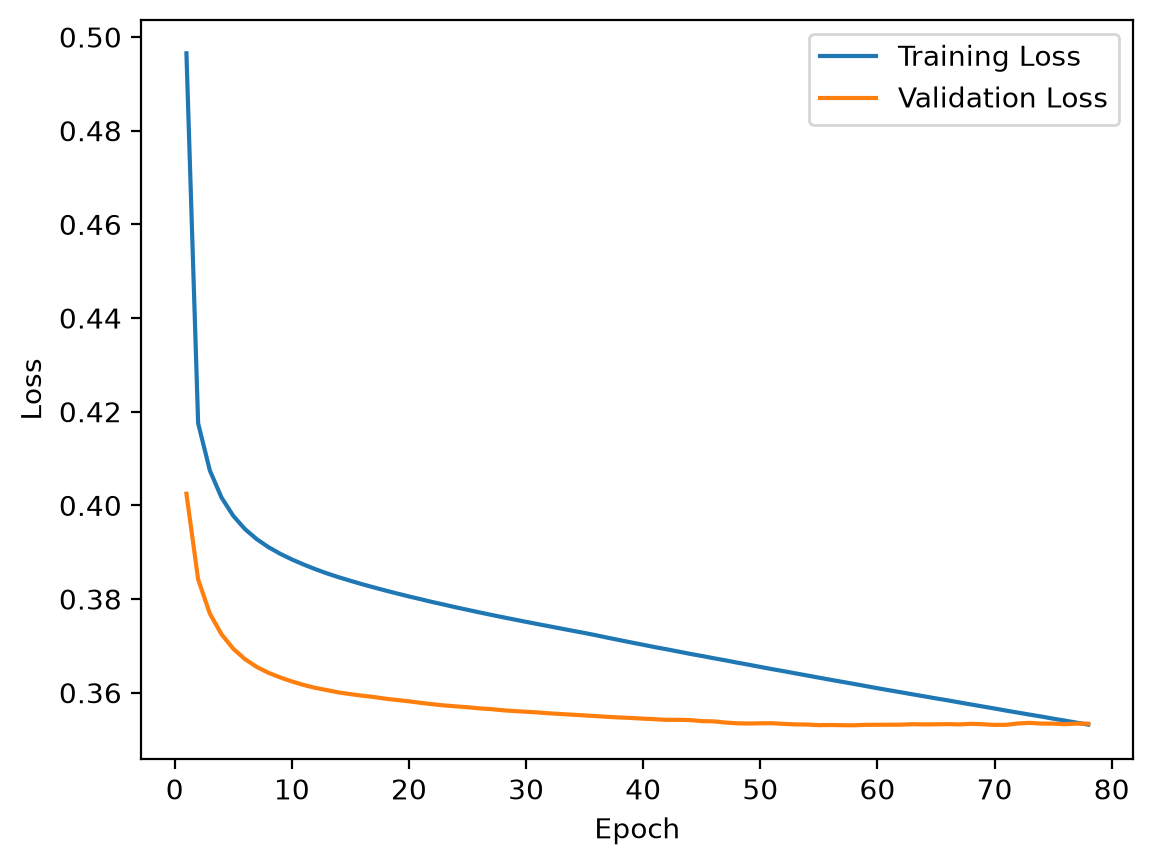

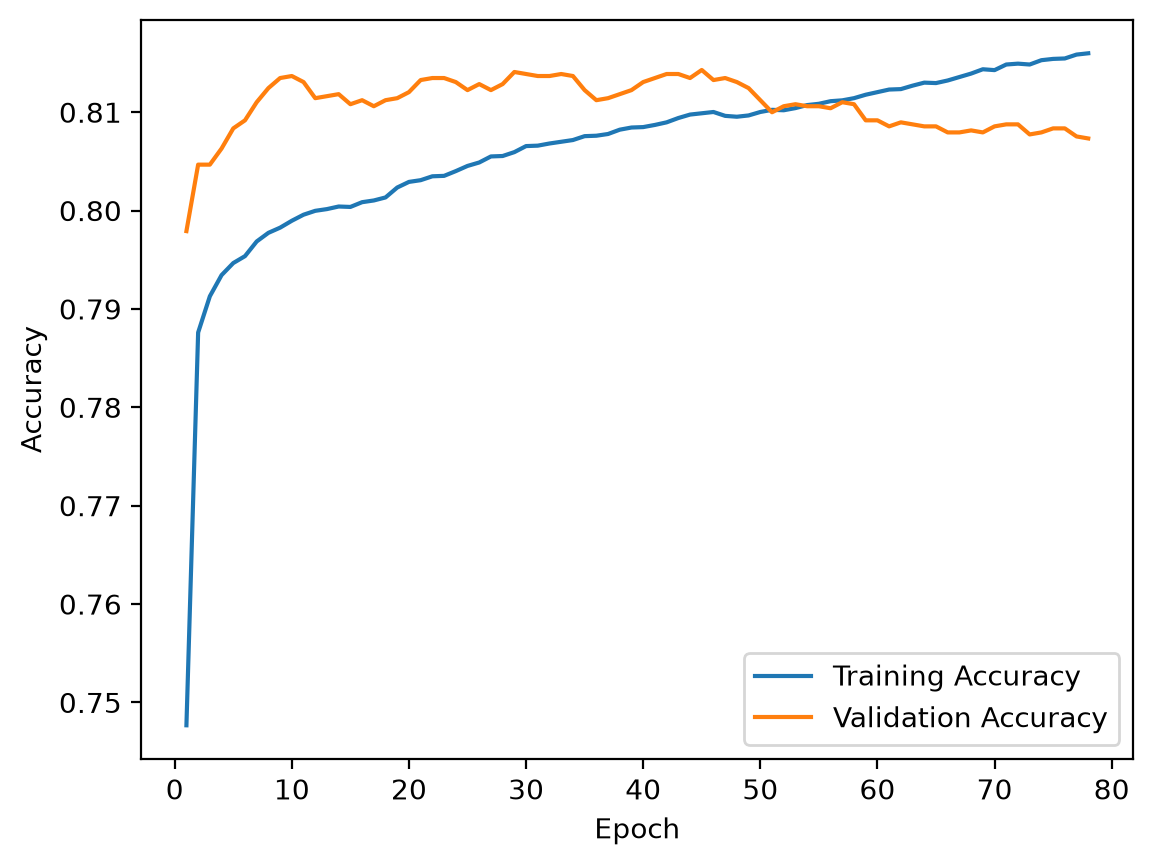

In [46]:
epochs_ran = len(history.history['loss'])

# Plot training and validation loss
plt.plot(range(1, epochs_ran + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, epochs_ran + 1), history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.plot(range(1, epochs_ran + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, epochs_ran + 1), history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### 6.2 Test metrics

The network threshold is chosen **only on validation predictions** using F1. That threshold is
then frozen and applied once to the final test probabilities. The test labels never
participate in threshold selection.

In [47]:
y_prob_nn_val = nn_model.predict(X_val_scaled, verbose=0).ravel()
nn_threshold, nn_val_f1 = select_f1_threshold(y_val, y_prob_nn_val)

y_prob_nn = nn_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_nn = pd.Series(
    (y_prob_nn >= nn_threshold).astype(int),
    index=y_test.index
)

nn_f1 = f1_score(y_test, y_pred_nn)
nn_acc = accuracy_score(y_test, y_pred_nn)

print(f"Validation-selected NN threshold: {nn_threshold:.2f} (validation F1={nn_val_f1:.4f})")
print(f"Test F1: {nn_f1:.4f}")
print(f"Test Accuracy: {nn_acc:.4f}")

Validation-selected NN threshold: 0.63 (validation F1=0.7248)
Test F1: 0.6964
Test Accuracy: 0.8299


In [48]:
print("F1:", nn_f1)
print("Accuracy:", nn_acc)

F1: 0.6963829009864816
Accuracy: 0.8298874104401228


In [49]:
female_mask_nn = X_test['is_female'] == 1
male_mask_nn = X_test['is_female'] == 0

recall_female_nn = recall_score(y_test[female_mask_nn], y_pred_nn[female_mask_nn])
recall_non_female_nn = recall_score(y_test[male_mask_nn], y_pred_nn[male_mask_nn])

print("Recall (female):", recall_female_nn)
print("Recall (non-female):", recall_non_female_nn)

Recall (female): 0.7391304347826086
Recall (non-female): 0.8235887096774194


### 6.3 Subgroup metrics, both models

The ad-hoc recall calls above give the headline number, but recall alone picks one error
type and percentages hide how few people are behind them. This reports counts alongside
rates, and adds precision so the other error direction is visible too.

In [50]:
def subgroup_report(y_true, y_pred, is_female, model_name):
    """Per-subgroup counts and rates."""
    rows = []
    for flag, name in [(1, 'female'), (0, 'non-female')]:
        m = (is_female == flag)
        yt, yp = y_true[m], y_pred[m]
        positives = int(yt.sum())
        tp = int(((yp == 1) & (yt == 1)).sum())
        pred_pos = int((yp == 1).sum())
        rows.append({
            'model': model_name,
            'group': name,
            'n': int(m.sum()),
            'positives': positives,
            'base rate': round(positives / int(m.sum()), 4),
            'true positives': tp,
            'recall': round(tp / positives, 4) if positives else float('nan'),
            'predicted positive': pred_pos,
            'precision': round(tp / pred_pos, 4) if pred_pos else float('nan'),
        })
    return pd.DataFrame(rows)


group = X_test['is_female']

subgroups = pd.concat([
    subgroup_report(y_test, y_pred_lr, group, 'logistic regression'),
    subgroup_report(y_test, y_pred_nn, group, 'neural network'),
], ignore_index=True)

subgroups

,model,group,n,positives,base rate,true positives,recall,predicted positive,precision
0,logistic regression,female,1640,184,0.1122,120,0.6522,192,0.6250
1,logistic regression,non-female,3245,992,0.3057,764,0.7702,1174,0.6508
2,neural network,female,1640,184,0.1122,136,0.7391,227,0.5991
3,neural network,non-female,3245,992,0.3057,817,0.8236,1334,0.6124


### 6.4 `fnlwgt`-weighted sensitivity

`fnlwgt` stays out of the feature matrix, but the test rows can still be reweighted when
reporting subgroup rates. This is a sensitivity check rather than a second trained model:
predictions stay exactly the same, and only the contribution of each test row to the reported
rate changes.


In [51]:
def weighted_subgroup_report(y_true, y_pred, is_female, sample_weight, model_name):
    rows = []
    for flag, name in [(1, 'female'), (0, 'non-female')]:
        m = (is_female == flag)
        yt = y_true[m]
        yp = y_pred[m]
        w = sample_weight[m]

        rows.append({
            'model': model_name,
            'group': name,
            'weighted base rate': np.average(yt, weights=w),
            'weighted recall': recall_score(yt, yp, sample_weight=w),
            'weighted precision': precision_score(yt, yp, sample_weight=w, zero_division=0),
        })
    return pd.DataFrame(rows)


test_weights = df.loc[X_test.index, 'fnlwgt'].astype(float)

weighted_subgroups = pd.concat([
    weighted_subgroup_report(
        y_test, y_pred_lr, group, test_weights, 'logistic regression'
    ),
    weighted_subgroup_report(
        y_test, y_pred_nn, group, test_weights, 'neural network'
    ),
], ignore_index=True)

weighted_subgroups.round(4)


,model,group,weighted base rate,weighted recall,weighted precision
0,logistic regression,female,0.1174,0.6472,0.6461
1,logistic regression,non-female,0.3030,0.7744,0.6768
2,neural network,female,0.1174,0.7388,0.6039
3,neural network,non-female,0.3030,0.8242,0.6298


### 6.5 Do the models differ on positive-case errors?

Both models are scored on the same test rows, so their errors are paired. McNemar's exact
test looks only at rows where one model is correct and the other is wrong. The test below is
restricted to actual positives because the comparison of interest here is recall; it therefore
does not test whether one model is universally better across all cases.


In [52]:
def mcnemar_exact(y_true, pred_a, pred_b, label_a='A', label_b='B'):
    a_right = (pred_a == y_true)
    b_right = (pred_b == y_true)
    n_a_only = int((a_right & ~b_right).sum())
    n_b_only = int((~a_right & b_right).sum())
    n_disagree = n_a_only + n_b_only
    p = binomtest(n_a_only, n_disagree, 0.5).pvalue if n_disagree else 1.0
    return {
        f'n_{label_a}_only': n_a_only,
        f'n_{label_b}_only': n_b_only,
        'n_disagree': n_disagree,
        'p_value': float(p),
    }


def print_mcnemar(label, result):
    print(
        f"{label:<22} "
        f"LR only={result['n_lr_only']}, "
        f"NN only={result['n_nn_only']}, "
        f"disagree={result['n_disagree']}, "
        f"p={result['p_value']:.3g}"
    )


# restricted to actual positives, since recall is what is in question
pos = y_test == 1

m_all = mcnemar_exact(y_test[pos], y_pred_lr[pos], y_pred_nn[pos], 'lr', 'nn')
m_female = mcnemar_exact(
    y_test[pos & (group == 1)],
    y_pred_lr[pos & (group == 1)],
    y_pred_nn[pos & (group == 1)],
    'lr', 'nn'
)
m_non_female = mcnemar_exact(
    y_test[pos & (group == 0)],
    y_pred_lr[pos & (group == 0)],
    y_pred_nn[pos & (group == 0)],
    'lr', 'nn'
)

print_mcnemar("all positives:", m_all)
print_mcnemar("female positives:", m_female)
print_mcnemar("non-female positives:", m_non_female)


all positives:         LR only=32, NN only=101, disagree=133, p=1.59e-09
female positives:      LR only=7, NN only=23, disagree=30, p=0.00522
non-female positives:  LR only=25, NN only=78, disagree=103, p=1.61e-07


## 7. Findings

In [53]:
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'Validation-selected threshold'],
    'Logistic Regression Model': [test_acc, test_f1, lr_threshold],
    'Neural Network': [nn_acc, nn_f1, nn_threshold],
}).round(4)

subgroup_recall = (
    subgroups.pivot(index='group', columns='model', values='recall')
    .rename_axis(index='Recall by Subgroup', columns=None)
)

print("--- Final Test Results by Model ---")
print(results.to_string(index=False))
print("\n")
print("--- Final Test Recall by Subgroup ---")
print(subgroup_recall.round(4).to_string())

--- Final Test Results by Model ---
                       Metric  Logistic Regression Model  Neural Network
                     Accuracy                     0.8416          0.8299
                     F1 Score                     0.6955          0.6964
Validation-selected threshold                     0.6200          0.6300


--- Final Test Recall by Subgroup ---
                    logistic regression  neural network
Recall by Subgroup                                     
female                           0.6522          0.7391
non-female                       0.7702          0.8236


### 7.1 Aggregate metrics

The table above is the final held-out comparison. Both decision thresholds were selected on
the validation partition and frozen before the test labels were used. That makes differences
in test F1, accuracy, and subgroup recall descriptive of the held-out test set rather than a
by-product of tuning directly against it.

### 7.2 The subgroup result

The `subgroups` table in section 6.3 is the main fairness result: it reports base rates,
counts, recall, and precision for female and non-female test rows under both models. Reading
counts alongside rates matters because a gap can narrow either because the lower-performing
group improves or because the higher-performing group gets worse.

### 7.3 Paired model comparison

Section 6.5 uses McNemar's exact test on the same positive test rows. This is preferable to
treating the two recalls as independent estimates because every person receives a prediction
from both models.

### 7.4 Weighted sensitivity

The `fnlwgt` table does not retrain either model. It asks whether the subgroup story changes
when test observations contribute in proportion to their census weight. Agreement between
the weighted and unweighted tables strengthens the interpretation; disagreement is a signal
that the sample composition matters materially.

### 7.5 Capital-gain robustness

`capital-gain` is no longer allowed to dominate merely because of the raw 99,999 upper-end
spike. The model now separates **having any gain** from the transformed amount, clips the
amount using a threshold learned only on training data, and logs the remaining scale. The
printed clipping threshold in section 5 makes the preprocessing decision auditable.

### 7.6 What aggregate accuracy can and can't see

The motivating point remains the same: a subgroup that is small in the full test set can have
poor recall without moving overall accuracy very much. Aggregate performance therefore
cannot substitute for subgroup reporting even when the aggregate model comparison is close.

## 8. Limitations and known issues

1. **One split, one seed.** The final test set is now cleanly held out, but subgroup rates are
   still point estimates from one seeded split. Repeated splits or bootstrap intervals would
   show how stable the gap is.
2. **Thresholds optimize global F1.** Validation-based threshold selection fixes test leakage,
   but it does not optimize a fairness criterion or calibration. Different decision objectives
   can change subgroup recall and precision.
3. **Only sex is broken out in detail.** Race and national origin remain model features but are
   not evaluated with the same subgroup reporting. Small cells make those estimates noisier,
   not irrelevant.
4. **Native country is still compressed.** The revised encoding preserves missingness instead
   of calling it US-native, but collapses all known non-US countries into one reference state.
5. **`fnlwgt` sensitivity is descriptive.** It is used to reweight reported test metrics, not
   as a training feature or a full survey-design analysis.
6. **Reference levels are mostly automatic.** `drop='first'` leaves categorical coefficient
   interpretation dependent on the encoder's category ordering.
7. **Coefficient interpretation is conditional, not causal.** This run selected L2 rather than
   L1, so the coefficient table is not a sparse feature-selection result. Correlated and
   mechanically related predictors can still make individual coefficients unstable or
   misleading when interpreted in isolation.
8. **Capital handling is a modeling choice.** A training-fitted 99th-percentile cap plus
   `log1p` is more stable than raw standardization, but another defensible treatment could
   produce somewhat different coefficients.
9. **1994 data.** Nothing here should be read as a claim about the present-day labor market.
10. **"Non-Female" is a schema relabeling.** The public loader maps the source `Male` category
    to `Non-Female` to match the course-file schema; the resulting label should not be
    interpreted as a modern gender-identity measure.

## 9. Next steps

- **Repeated splits or bootstrap intervals** for subgroup recall and precision.
- **Calibration by subgroup** and explicit threshold trade-off curves, rather than optimizing
  only global F1.
- **Gradient-boosted trees** as a strong tabular third model family.
- **More fairness metrics**, including false-positive-rate gaps and equalized-odds summaries.
- **Deliberate reference levels** for categorical coefficient interpretation.
- **Richer native-country grouping** if that feature becomes substantively important.